In [12]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

import matplotlib.pyplot as plt

In [13]:

SEED = 42
FOLDS = [0, 1, 2, 3]           

ACTIVE_STAGE = "stage05"
RUN_NAME = "baseline"
assert ACTIVE_STAGE != RUN_NAME, (
    "ACTIVE_STAGE is the U-Net being compared against, RUN_NAME is the baseline. "
    "Equal values compare the baseline with itself."
)

# perClassEvaluation.ipynb builds its model path as
#   f"{ACTIVE_STAGE}fold{fold}bubble_unet.keras"
MODEL_FILE_SUFFIX = "bubble_unet"

RUN_TAG = "postproc_"

EPOCHS = 100
BATCH_SIZE = 4
WEIGHT = 2.0            # foreground up-weight inside the BCE term
TVERSKY_ALPHA = 0.5     # weights false negatives
TVERSKY_BETA = 0.5      # weights false positives; alpha = beta = 0.5 IS Dice
EARLY_STOPPING_PATIENCE = 15
LEARNING_RATE = 1e-4

MODEL_DIR = Path("../outputs/models")
OUTPUT_DIR = Path("../outputs")
HISTORY_DIR = Path("../outputs/history")   # where modelTraining puts its histories
EVAL_DIR = Path("../outputs/predictions")  # where perClassEvaluation puts its tables
PLOTS_DIR = "../outputs/figures/plots"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)


def fold_paths(fold):
    return {
        "aug_dir": f"../data/processed/augmented/fold{fold}",
        "tag": f"{RUN_NAME}fold{fold}",
    }


missing = [f"  fold {f}: {fold_paths(f)['aug_dir']}"
           for f in FOLDS if not os.path.isdir(fold_paths(f)["aug_dir"])]
if missing:
    raise FileNotFoundError(
        "No augmented arrays for:\n" + "\n".join(missing) +
        "\n\nRun modelTraining.ipynb with the same FOLDS first - this notebook "
        "consumes the fold data it writes."
    )

print(f"ACTIVE_STAGE={ACTIVE_STAGE} (reference U-Net)  RUN_NAME={RUN_NAME} (baseline)")
print(f"FOLDS={FOLDS}")
for f in FOLDS:
    print(f"  fold {f}: {fold_paths(f)['aug_dir']} -> {fold_paths(f)['tag']}")

ACTIVE_STAGE=stage05 (reference U-Net)  RUN_NAME=baseline (baseline)
FOLDS=[0, 1, 2, 3]
  fold 0: ../data/processed/augmented/fold0 -> baselinefold0
  fold 1: ../data/processed/augmented/fold1 -> baselinefold1
  fold 2: ../data/processed/augmented/fold2 -> baselinefold2
  fold 3: ../data/processed/augmented/fold3 -> baselinefold3


In [14]:
# --- baseline architecture, from predictionsBaseline.ipynb ----------

def build_baseline(input_shape=(256, 256, 1)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(16, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)

    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(x)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(x)

    return models.Model(inputs, outputs, name="bubble_baseline")


_m = build_baseline()
print(f"baseline parameters : {_m.count_params():>10,}")
print(f"U-Net parameters    : {1968225:>10,}   (stage05fold0, for reference)")
print(f"ratio               : {1968225 / _m.count_params():>10.1f}x")
del _m

baseline parameters :     46,401
U-Net parameters    :  1,968,225   (stage05fold0, for reference)
ratio               :       42.4x


In [15]:
# --- losses and metrics, identical to modelTraining.ipynb --------------------

def unpack(y_true):
    if y_true.shape[-1] == 2:
        return y_true[..., :1], y_true[..., 1:2]
    return y_true, tf.ones_like(y_true)


def tversky_loss(y_true, y_pred, smooth=1, alpha=None, beta=None):
    alpha = TVERSKY_ALPHA if alpha is None else alpha
    beta = TVERSKY_BETA if beta is None else beta

    y_t, w = unpack(y_true)
    y_t = tf.reshape(y_t, [-1]); w = tf.reshape(w, [-1]); y_p = tf.reshape(y_pred, [-1])

    true_pos = tf.reduce_sum(w * y_t * y_p)
    false_neg = tf.reduce_sum(w * y_t * (1 - y_p))
    false_pos = tf.reduce_sum(w * (1 - y_t) * y_p)

    return 1 - (2 * true_pos + smooth) / (
        2 * true_pos + 2 * alpha * false_neg + 2 * beta * false_pos + smooth
    )


def weighted_bce(y_true, y_pred):
    y_t, w = unpack(y_true)
    y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())
    weights = y_t * WEIGHT + 1
    bce = tf.keras.backend.binary_crossentropy(y_t, y_pred)
    return tf.reduce_sum(w * weights * bce) / (tf.reduce_sum(w) + 1e-7)


def combined_loss(y_true, y_pred):
    return weighted_bce(y_true, y_pred) + tversky_loss(y_true, y_pred)


def dice_coef(y_true, y_pred, smooth=1):
    y_t, w = unpack(y_true)
    y_t = tf.reshape(y_t, [-1]); w = tf.reshape(w, [-1]); y_p = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(w * y_t * y_p)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(w * y_t) + tf.reduce_sum(w * y_p) + smooth
    )


def iou_coef(y_true, y_pred, smooth=1):
    y_t, w = unpack(y_true)
    y_t = tf.reshape(y_t, [-1]); w = tf.reshape(w, [-1]); y_p = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(w * y_t * y_p)
    union = tf.reduce_sum(w * y_t) + tf.reduce_sum(w * y_p) - intersection
    return (intersection + smooth) / (union + smooth)


# same self-check as modelTraining: masked == unmasked on all-ones weights, and
# Tversky(0.5, 0.5) is Dice
_rng = np.random.default_rng(0)
_y = tf.constant(_rng.integers(0, 2, (2, 32, 32, 1)), dtype=tf.float32)
_w = tf.ones_like(_y)
_p = tf.constant(_rng.random((2, 32, 32, 1)), dtype=tf.float32)
_packed = tf.concat([_y, _w], axis=-1)
assert abs(float(dice_coef(_packed, _p)) - float(dice_coef(_y, _p))) < 1e-5
assert abs(float(tversky_loss(_packed, _p, alpha=0.5, beta=0.5))
           - float(1 - dice_coef(_packed, _p))) < 1e-5
print("masked loss/metric self-check passed")

masked loss/metric self-check passed


In [16]:
def run_fold(fold):
    paths = fold_paths(fold)
    tag = paths["tag"]
    aug = paths["aug_dir"]

    print(f"\n{'=' * 70}\nBASELINE  fold {fold}   tag={tag}\n{'=' * 70}")

    tf.keras.utils.set_random_seed(SEED)

    X_train = np.load(os.path.join(aug, "XtrainAug.npy")).astype(np.float32)
    Y_train = np.load(os.path.join(aug, "YtrainAug.npy")).astype(np.float32)
    X_val = np.load(os.path.join(aug, "Xval.npy")).astype(np.float32)
    Y_val = np.load(os.path.join(aug, "Yval.npy")).astype(np.float32)

    W_train_p = os.path.join(aug, "WtrainAug.npy")
    W_val_p = os.path.join(aug, "Wval.npy")
    if os.path.exists(W_train_p) and os.path.exists(W_val_p):
        W_train = np.load(W_train_p).astype(np.float32)
        W_val = np.load(W_val_p).astype(np.float32)
    else:
        W_train, W_val = np.ones_like(Y_train), np.ones_like(Y_val)

    print(f"train {X_train.shape[0]} patches | val {X_val.shape[0]} patches")
    print(f"foreground train {Y_train.mean():.4f} val {Y_val.mean():.4f} | "
          f"supervised {W_train.mean():.4f}")

    YW_train = np.concatenate([Y_train, W_train], axis=-1)
    YW_val = np.concatenate([Y_val, W_val], axis=-1)

    model = build_baseline()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=combined_loss,
        metrics=[dice_coef, iou_coef],
    )

    best_weights = os.path.join(MODEL_DIR, f"{tag}{MODEL_FILE_SUFFIX}_best.weights.h5")
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(str(best_weights), monitor="val_dice_coef",
                                           mode="max", save_best_only=True,
                                           save_weights_only=True, verbose=0),
        tf.keras.callbacks.EarlyStopping(monitor="val_dice_coef", mode="max",
                                         patience=EARLY_STOPPING_PATIENCE,
                                         restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5,
                                             patience=6, min_lr=1e-6, verbose=0),
        tf.keras.callbacks.CSVLogger(str(HISTORY_DIR / f"{tag}training_history.csv")),
    ]

    history = model.fit(
        X_train, YW_train,
        validation_data=(X_val, YW_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE, shuffle=True,
        callbacks=callbacks, verbose=2,
    )
    model.load_weights(best_weights)

    # threshold sweep over supervised pixels only
    preds_val = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0)

    def dice_at(t):
        b = (preds_val > t).astype(np.float32)
        inter = np.sum(W_val * Y_val * b)
        return (2 * inter + 1) / (np.sum(W_val * Y_val) + np.sum(W_val * b) + 1)

    sweep = [(float(t), float(dice_at(t)),
              float((W_val * (preds_val > t)).sum() / W_val.sum()))
             for t in np.arange(0.05, 0.951, 0.025)]
    best_threshold, best_dice, best_fg = max(sweep, key=lambda r: r[1])

    model_path = os.path.join(MODEL_DIR, f"{tag}{MODEL_FILE_SUFFIX}.keras")
    model.save(model_path)

    with open(HISTORY_DIR / f"{tag}training_history.json", "w") as fh:
        json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()},
                  fh, indent=2)

    run_config = {
        "run_name": RUN_NAME, "architecture": "baseline",
        "active_stage": ACTIVE_STAGE, "fold": fold,
        "tversky_alpha": TVERSKY_ALPHA, "tversky_beta": TVERSKY_BETA,
        "bce_weight": WEIGHT, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE, "seed": SEED,
        "params": int(model.count_params()),
        "n_train_patches": int(X_train.shape[0]), "n_val_patches": int(X_val.shape[0]),
        "train_supervised_ratio": float(W_train.mean()),
        "val_supervised_ratio": float(W_val.mean()),
        "aug_dir": aug,
    }
    with open(HISTORY_DIR / f"{tag}runConfig.json", "w") as fh:
        json.dump(run_config, fh, indent=2)

    gt_foreground = float((Y_val * W_val).sum() / W_val.sum())
    with open(HISTORY_DIR / f"{tag}threshold_summary.json", "w") as fh:
        json.dump({"run_name": RUN_NAME, "fold": fold,
                   "best_threshold": best_threshold, "validation_dice": best_dice,
                   "predicted_foreground_ratio": best_fg,
                   "ground_truth_foreground_ratio": gt_foreground},
                  fh, indent=2)

    best_epoch = int(np.argmax(history.history["val_dice_coef"]))
    result = {
        "fold": fold, "tag": tag, "params": int(model.count_params()),
        "n_train": int(X_train.shape[0]), "n_val": int(X_val.shape[0]),
        "epochs_run": len(history.history["loss"]), "best_epoch": best_epoch,
        "val_dice_soft": float(history.history["val_dice_coef"][best_epoch]),
        "train_dice_soft": float(history.history["dice_coef"][best_epoch]),
        "best_threshold": best_threshold, "val_dice_hard": best_dice,
        "pred_foreground": best_fg, "gt_foreground": gt_foreground,
    }
    result["train_val_gap"] = result["train_dice_soft"] - result["val_dice_soft"]
    # how far the model over-paints relative to the truth it is fitting. A model
    # that paints everything scores high recall for free, so this ratio is what
    # tells the comparison cells whether a fold's recall means anything.
    result["overpaint"] = best_fg / gt_foreground

    print(f"\nfold {fold}: best epoch {best_epoch}, val dice {best_dice:.4f} "
          f"at t={best_threshold:.3f}, gap {result['train_val_gap']:.4f}, "
          f"painted {best_fg:.3f} vs truth {gt_foreground:.3f} "
          f"({result['overpaint']:.1f}x)")
    print("saved:", model_path)

    return result, history

In [6]:
results, histories = [], {}
for fold in FOLDS:
    result, history = run_fold(fold)
    results.append(result)
    histories[fold] = history

results_df = pd.DataFrame(results)
print("\n" + "=" * 70)
print(results_df.to_string(index=False, float_format="%.4f"))

summary_path = HISTORY_DIR / f"{RUN_NAME}foldSummary.csv"
results_df.to_csv(summary_path, index=False)
print("\nwrote", summary_path)


BASELINE  fold 0   tag=baselinefold0
train 344 patches | val 24 patches
foreground train 0.2311 val 0.1466 | supervised 1.0000
Epoch 1/100
86/86 - 10s - 113ms/step - dice_coef: 0.3137 - iou_coef: 0.1882 - loss: 1.7026 - val_dice_coef: 0.2267 - val_iou_coef: 0.1294 - val_loss: 1.6731 - learning_rate: 1.0000e-04
Epoch 2/100
86/86 - 9s - 100ms/step - dice_coef: 0.3149 - iou_coef: 0.1890 - loss: 1.6994 - val_dice_coef: 0.2355 - val_iou_coef: 0.1351 - val_loss: 1.6185 - learning_rate: 1.0000e-04
Epoch 3/100
86/86 - 9s - 100ms/step - dice_coef: 0.3184 - iou_coef: 0.1914 - loss: 1.6850 - val_dice_coef: 0.2870 - val_iou_coef: 0.1700 - val_loss: 1.4264 - learning_rate: 1.0000e-04
Epoch 4/100
86/86 - 9s - 100ms/step - dice_coef: 0.3231 - iou_coef: 0.1947 - loss: 1.6711 - val_dice_coef: 0.3010 - val_iou_coef: 0.1802 - val_loss: 1.3842 - learning_rate: 1.0000e-04
Epoch 5/100
86/86 - 9s - 100ms/step - dice_coef: 0.3257 - iou_coef: 0.1966 - loss: 1.6623 - val_dice_coef: 0.3068 - val_iou_coef: 0.184

In [17]:
# --- paired comparison against the U-Net, fold by fold ------------------------

unet_summary = HISTORY_DIR / f"{ACTIVE_STAGE}foldSummary.csv"
base_summary = HISTORY_DIR / f"{RUN_NAME}foldSummary.csv"
assert unet_summary != base_summary, "both sides resolve to the same file"

_absent = [p for p in (unet_summary, base_summary) if not p.exists()]
if _absent:
    print("missing:\n  " + "\n  ".join(str(p) for p in _absent) +
          "\n\nRe-run the summary cell of modelTraining.ipynb (U-Net) or this "
          "notebook (baseline) to produce them.")
else:
    unet = pd.read_csv(unet_summary).set_index("fold")
    base = pd.read_csv(base_summary).set_index("fold")
    common = sorted(set(unet.index) & set(base.index))

    # same held-out patches on both sides, or nothing below is a comparison
    for f in common:
        assert unet.loc[f, "n_val"] == base.loc[f, "n_val"], (
            f"fold {f}: {unet.loc[f, 'n_val']} val patches for the U-Net but "
            f"{base.loc[f, 'n_val']} for the baseline - not the same held-out sky"
        )

    cmp = pd.DataFrame([
        dict(fold=f,
             unet=unet.loc[f, "val_dice_hard"],
             baseline=base.loc[f, "val_dice_hard"],
             delta=unet.loc[f, "val_dice_hard"] - base.loc[f, "val_dice_hard"],
             unet_painted=unet.loc[f, "pred_foreground"],
             base_painted=base.loc[f, "pred_foreground"])
        for f in common
    ])
    print(cmp.to_string(index=False, float_format="%.4f"))

    d = cmp["delta"].values
    mean, se = d.mean(), d.std(ddof=1) / np.sqrt(len(d))
    consistent = bool(np.all(d > 0) or np.all(d < 0))

    # parameter counts read from the run configs rather than restated here
    with open(HISTORY_DIR / f"{ACTIVE_STAGE}fold{common[0]}runConfig.json") as fh:
        unet_params = json.load(fh)["params"]
    base_params = int(base["params"].iloc[0])

    print(f"\nU-Net minus baseline, hard val dice:")
    print(f"  mean {mean:+.4f}   se {se:.4f}   t {mean / se if se else float('nan'):+.2f}")
    print(f"  same sign in all {len(d)} folds: {consistent}")
    print(f"  parameters: U-Net {unet_params:,} vs baseline {base_params:,} "
          f"({unet_params / base_params:.1f}x)")
    if not consistent:
        print("\n  NOT consistent across folds - do not quote the mean as a result. "
              "Report the per-fold values and say the difference is fold-dependent.")

    if "gt_foreground" in base.columns:
        print("\npainted / true foreground, baseline:")
        for f in common:
            ratio = base.loc[f, "pred_foreground"] / base.loc[f, "gt_foreground"]
            print(f"  fold {f}: {base.loc[f, 'pred_foreground']:.3f} / "
                  f"{base.loc[f, 'gt_foreground']:.3f} = {ratio:.1f}x")

 fold   unet  baseline   delta  unet_painted  base_painted
    0 0.4471    0.3856  0.0615        0.3136        0.2483
    1 0.5424    0.4782  0.0642        0.4646        0.9649
    2 0.4021    0.4341 -0.0320        0.2243        0.1538
    3 0.5015    0.4874  0.0142        0.4213        0.4354

U-Net minus baseline, hard val dice:
  mean +0.0270   se 0.0228   t +1.19
  same sign in all 4 folds: False
  parameters: U-Net 1,968,225 vs baseline 46,401 (42.4x)

  NOT consistent across folds - do not quote the mean as a result. Report the per-fold values and say the difference is fold-dependent.

painted / true foreground, baseline:
  fold 0: 0.248 / 0.147 = 1.7x
  fold 1: 0.965 / 0.303 = 3.2x
  fold 2: 0.154 / 0.126 = 1.2x
  fold 3: 0.435 / 0.246 = 1.8x


In [18]:
# --- per-class comparison: object recall, precision, and the chance floor -----

SIZE_ORDER = ["edgeLarge", "giants", "large", "medium", "small", "tiny"]


def eval_paths(stage):
    return {
        "per_fold": EVAL_DIR / f"{stage}{RUN_TAG}perFoldPerClass.csv",
        "pooled_bubbles": EVAL_DIR / f"{stage}{RUN_TAG}pooledPerBubbleCoverage.csv",
        "chance": {f: EVAL_DIR / f"{stage}fold{f}{RUN_TAG}chanceCoverageControl.csv"
                   for f in FOLDS},
    }


MODELS = {"unet": ACTIVE_STAGE, "baseline": RUN_NAME}

_needed = [p for stage in MODELS.values()
           for p in (eval_paths(stage)["per_fold"], eval_paths(stage)["pooled_bubbles"],
                     *eval_paths(stage)["chance"].values())]
_absent = [p for p in _needed if not p.exists()]
if _absent:
    raise FileNotFoundError(
        "Missing evaluation tables:\n  " + "\n  ".join(str(p) for p in _absent) +
        f"\n\nRun perClassEvaluation.ipynb with FOLDS={FOLDS}, RUN_TAG='{RUN_TAG}' "
        f"and ACTIVE_STAGE set to each of {list(MODELS.values())}."
    )

per_fold = {m: pd.read_csv(eval_paths(s)["per_fold"]) for m, s in MODELS.items()}
bubbles = {m: pd.read_csv(eval_paths(s)["pooled_bubbles"]) for m, s in MODELS.items()}
chance = {m: {f: pd.read_csv(p) for f, p in eval_paths(s)["chance"].items()}
          for m, s in MODELS.items()}

# both models must have been graded on the same bubbles with the same blob floor
for m in MODELS:
    assert set(per_fold[m]["pp_min_blob_px"]) == set(per_fold["unet"]["pp_min_blob_px"]), (
        f"{m} was graded with a different MIN_BLOB_PX - regrade with matching flags"
    )
_counts = {m: bubbles[m].groupby("size_class").size().to_dict() for m in MODELS}
assert _counts["unet"] == _counts["baseline"], (
    f"different bubbles graded:\n  unet {_counts['unet']}\n  baseline {_counts['baseline']}"
)

at_chance = {}
for m in MODELS:
    at_chance[m] = []
    for f in FOLDS:
        c = chance[m][f]
        informative = (c["observed_recall"] > c["chance_recall_p95"]).sum()
        if informative == 0:
            at_chance[m].append(f)

# drop a fold from BOTH models if either is at chance there, so the two are
# always pooled over the same sky
dropped = sorted(set(at_chance["unet"]) | set(at_chance["baseline"]))
kept = [f for f in FOLDS if f not in dropped]

print("per-fold, both models:\n")
print(f"{'fold':<6}{'model':<10}{'prec':>7}{'blobs':>8}{'spur':>7}{'painted':>9}"
      f"{'informative classes':>22}")
for f in FOLDS:
    for m in MODELS:
        r = per_fold[m][per_fold[m]["fold"] == f].iloc[0]
        c = chance[m][f]
        n_inf = int((c["observed_recall"] > c["chance_recall_p95"]).sum())
        flag = "  <- at chance" if f in at_chance[m] else ""
        print(f"{f:<6}{m:<10}{r['global_precision']:>7.3f}"
              f"{int(r['global_n_pred_blobs']):>8}{int(r['global_n_spurious']):>7}"
              f"{r['pp_painted_fraction']:>9.3f}{n_inf:>15}/{len(c)}{flag}")

if dropped:
    print(f"\nfolds {dropped} carry no information for at least one model and are "
          f"excluded from the pooled table below. Pooling over folds {kept}.")
else:
    print(f"\nall folds clear their chance floor; pooling over {kept}.")


# --- pooled per class, over the retained folds -------------------------------

def pooled(df, folds):
    sub = df[df["fold"].isin(folds)]
    g = sub.groupby("size_class")
    out = pd.DataFrame({
        "n_bubbles": g.size(),
        "n_detected": g["detected"].sum(),
        "object_recall": g["detected"].mean(),
        "chance_recall": g["null_rate"].mean(),
    })
    return out.reindex([c for c in SIZE_ORDER if c in out.index])


pu, pb = pooled(bubbles["unet"], kept), pooled(bubbles["baseline"], kept)

comparison = pd.DataFrame(index=pu.index)
comparison["n_bubbles"] = pu["n_bubbles"].astype(int)
comparison["recall_unet"] = pu["object_recall"]
comparison["recall_baseline"] = pb["object_recall"]
comparison["recall_delta"] = pu["object_recall"] - pb["object_recall"]
comparison["excess_unet"] = pu["object_recall"] - pu["chance_recall"]
comparison["excess_baseline"] = pb["object_recall"] - pb["chance_recall"]
comparison["excess_delta"] = comparison["excess_unet"] - comparison["excess_baseline"]

# pooled precision from the blob counts of the retained folds, not a mean of means
prec = {}
for m in MODELS:
    r = per_fold[m][per_fold[m]["fold"].isin(kept)].drop_duplicates("fold")
    blobs_n, spur_n = r["global_n_pred_blobs"].sum(), r["global_n_spurious"].sum()
    prec[m] = dict(precision=(blobs_n - spur_n) / blobs_n, blobs=int(blobs_n),
                   spurious=int(spur_n))

print("\npooled over folds", kept, "\n")
print(comparison.to_string(float_format="%.3f"))
print(f"\nprecision   unet {prec['unet']['precision']:.3f} "
      f"({prec['unet']['blobs']} blobs, {prec['unet']['spurious']} spurious)")
print(f"            base {prec['baseline']['precision']:.3f} "
      f"({prec['baseline']['blobs']} blobs, {prec['baseline']['spurious']} spurious)")
print(f"            the baseline emits "
      f"{prec['baseline']['blobs'] / prec['unet']['blobs']:.1f}x as many blobs")

out_csv = EVAL_DIR / f"{RUN_NAME}{RUN_TAG}modelComparison.csv"
comparison.to_csv(out_csv)
print("\nwrote", out_csv)

per-fold, both models:

fold  model        prec   blobs   spur  painted   informative classes
0     unet        0.516     864    418    0.329              5/6
0     baseline    0.377    3381   2105    0.307              5/6
1     unet        0.620    1004    382    0.259              6/6
1     baseline    0.837     172     28    0.965              0/6  <- at chance
2     unet        0.560     966    425    0.197              6/6
2     baseline    0.278    4185   3023    0.309              6/6
3     unet        0.616    1262    485    0.432              5/6
3     baseline    0.567    3586   1551    0.278              5/6

folds [1] carry no information for at least one model and are excluded from the pooled table below. Pooling over folds [0, 2, 3].

pooled over folds [0, 2, 3] 

            n_bubbles  recall_unet  recall_baseline  recall_delta  excess_unet  excess_baseline  excess_delta
size_class                                                                                          

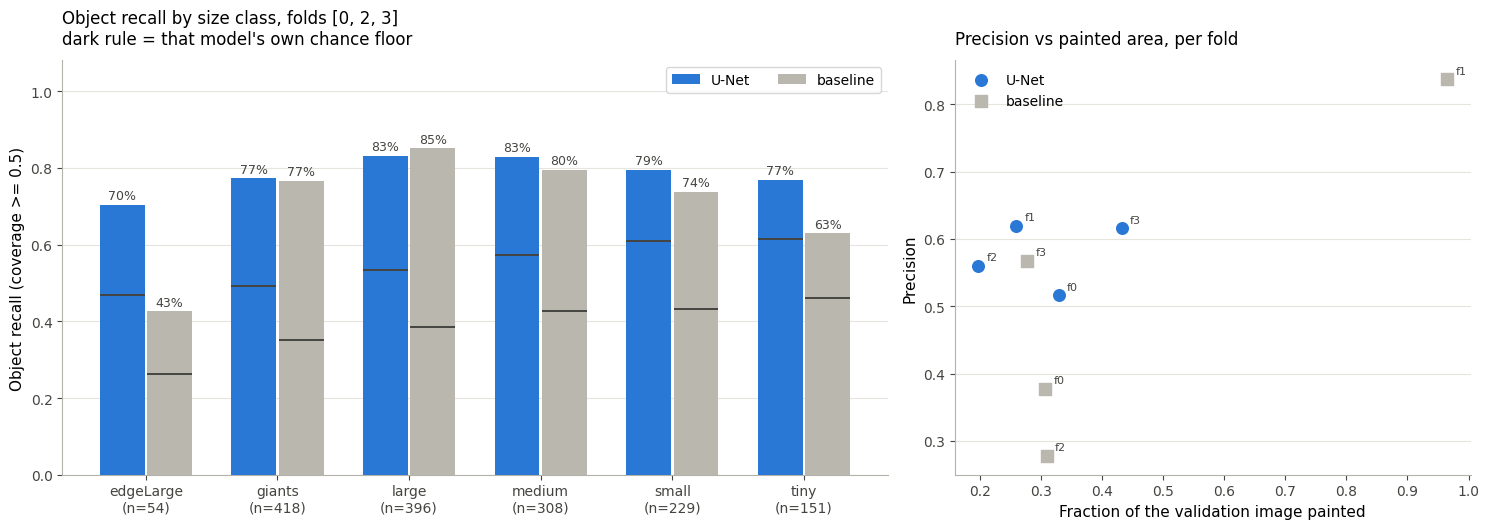

wrote ../outputs/figures/plots/baselinepostproc_modelComparison.pdf


In [23]:
# --- the comparison figure ----------------------------------------------------

BLUE, GRAY, INK = "#2a78d6", "#b9b7ae", "#444441"

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4),
                         gridspec_kw={"width_ratios": [1.6, 1]})

# --- panel 1: object recall per class, with each model's own chance floor
ax = axes[0]
classes = comparison.index.tolist()
xs = np.arange(len(classes))
width = 0.34

for k, (name, series, floor, colour) in enumerate([
        ("U-Net", comparison["recall_unet"], pu["chance_recall"], BLUE),
        ("baseline", comparison["recall_baseline"], pb["chance_recall"], GRAY)]):
    offs = xs + (k - 0.5) * (width + 0.02)
    ax.bar(offs, series.values, width=width, color=colour, label=name, zorder=3)
    # the chance floor for THIS model - it rises with how much the model paints,
    # so the two floors are not the same line
    ax.hlines(floor.values, offs - width / 2, offs + width / 2,
              color=INK, lw=1.4, zorder=4)
    for x, v in zip(offs, series.values):
        ax.text(x, v + 0.015, f"{v:.0%}", ha="center", fontsize=9, color=INK)

ax.set_xticks(xs)
ax.set_xticklabels([f"{c}\n(n={int(comparison.loc[c, 'n_bubbles'])})" for c in classes],
                   fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Object recall (coverage >= 0.5)", fontsize=11)
ax.set_title(f"Object recall by size class, folds {kept}"
             "\ndark rule = that model's own chance floor",
             fontsize=12, loc="left", pad=12)
ax.legend(frameon=True, fontsize=10, ncol=2, loc="upper right")

# --- panel 2: precision against how much of the image each fold painted
ax = axes[1]
for m, colour, marker in [("unet", BLUE, "o"), ("baseline", GRAY, "s")]:
    r = per_fold[m].drop_duplicates("fold")
    ax.scatter(r["pp_painted_fraction"], r["global_precision"],
               s=70, color=colour, marker=marker, zorder=3,
               label="U-Net" if m == "unet" else "baseline")
    for _, row in r.iterrows():
        ax.annotate(f"f{int(row['fold'])}",
                    (row["pp_painted_fraction"], row["global_precision"]),
                    textcoords="offset points", xytext=(6, 4),
                    fontsize=8, color=INK)

ax.set_xlabel("Fraction of the validation image painted", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision vs painted area, per fold", fontsize=12, loc="left", pad=12)
ax.legend(frameon=False, fontsize=10)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#b4b2a9")
    ax.tick_params(colors=INK)
    ax.grid(axis="y", color="#e6e4dc", lw=0.8, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, f"{RUN_NAME}{RUN_TAG}modelComparison.pdf")
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("wrote", out)


In [20]:
OPERATING_T = 0.5   # must equal BIN_THRESHOLD in perClassEvaluation.ipynb

sweeps = {}
for m, stage in MODELS.items():
    p = EVAL_DIR / f"{stage}{RUN_TAG}thresholdSweep.csv"
    if not p.exists():
        raise FileNotFoundError(
            f"{p} missing - run the sweep cell in perClassEvaluation.ipynb with "
            f"ACTIVE_STAGE = '{stage}' first."
        )
    sweeps[m] = pd.read_csv(p)

# same folds as the headline comparison, and the same excluded fold
sweeps = {m: s[s["fold"].isin(kept)] for m, s in sweeps.items()}


def curve(s, size_class):
    cls = s[s["size_class"] == size_class]
    g = cls.groupby("threshold")
    rec = g["n_detected"].sum() / g["n_bubbles"].sum()

    # precision pooled from blob counts, one row per fold per threshold
    tot = s.drop_duplicates(["fold", "threshold"]).groupby("threshold")
    blobs, spur = tot["n_pred_blobs"].sum(), tot["n_spurious"].sum()

    out = pd.DataFrame({
        "object_recall": rec,
        "precision": (blobs - spur) / blobs,
        "n_pred_blobs": blobs,
        "median_blob_px": tot["median_blob_px"].median(),
        "painted": tot["painted_fraction"].mean(),
    })
    # a threshold where the class never clears its own chance floor in any kept
    # fold is not an operating point, it is the degenerate end of the curve
    clears = cls.assign(ok=cls["object_recall"] > cls["chance_p95"]).groupby("threshold")["ok"].any()
    out["informative"] = clears.reindex(out.index).fillna(True)
    return out


classes = comparison.index.tolist()
verdict = []
for c in classes:
    cu, cb = curve(sweeps["unet"], c), curve(sweeps["baseline"], c)

    if OPERATING_T not in cb.index:
        raise ValueError(f"{OPERATING_T} not on the swept grid: {list(cb.index)}")
    b_rec, b_prec = cb.loc[OPERATING_T, "object_recall"], cb.loc[OPERATING_T, "precision"]

    # U-Net thresholds that match or beat the baseline's recall, degenerate
    # points excluded
    cand = cu[(cu["object_recall"] >= b_rec) & cu["informative"]]
    if cand.empty:
        best_t, best_prec, reach = np.nan, np.nan, "recall unreachable"
    else:
        best_t = cand["precision"].idxmax()
        best_prec = cand.loc[best_t, "precision"]
        reach = "reachable" if best_prec >= b_prec else "NOT reachable"

    verdict.append(dict(size_class=c, base_recall=b_rec, base_precision=b_prec,
                        unet_t=best_t, unet_precision=best_prec,
                        precision_gap=best_prec - b_prec, verdict=reach))

verdict = pd.DataFrame(verdict).set_index("size_class")
print(f"baseline operating point at t={OPERATING_T}, folds {kept}\n")
print(verdict.to_string(float_format="%.3f"))

out_csv = EVAL_DIR / f"{RUN_NAME}{RUN_TAG}reachability.csv"
verdict.to_csv(out_csv)
print("\nwrote", out_csv)


baseline operating point at t=0.5, folds [0, 2, 3]

            base_recall  base_precision  unet_t  unet_precision  precision_gap    verdict
size_class                                                                               
edgeLarge         0.426           0.401   0.700           0.646          0.245  reachable
giants            0.766           0.401   0.500           0.571          0.169  reachable
large             0.851           0.401   0.450           0.524          0.123  reachable
medium            0.795           0.401   0.500           0.571          0.169  reachable
small             0.738           0.401   0.550           0.591          0.190  reachable
tiny              0.629           0.401   0.550           0.591          0.190  reachable

wrote ../outputs/predictions/baselinepostproc_reachability.csv


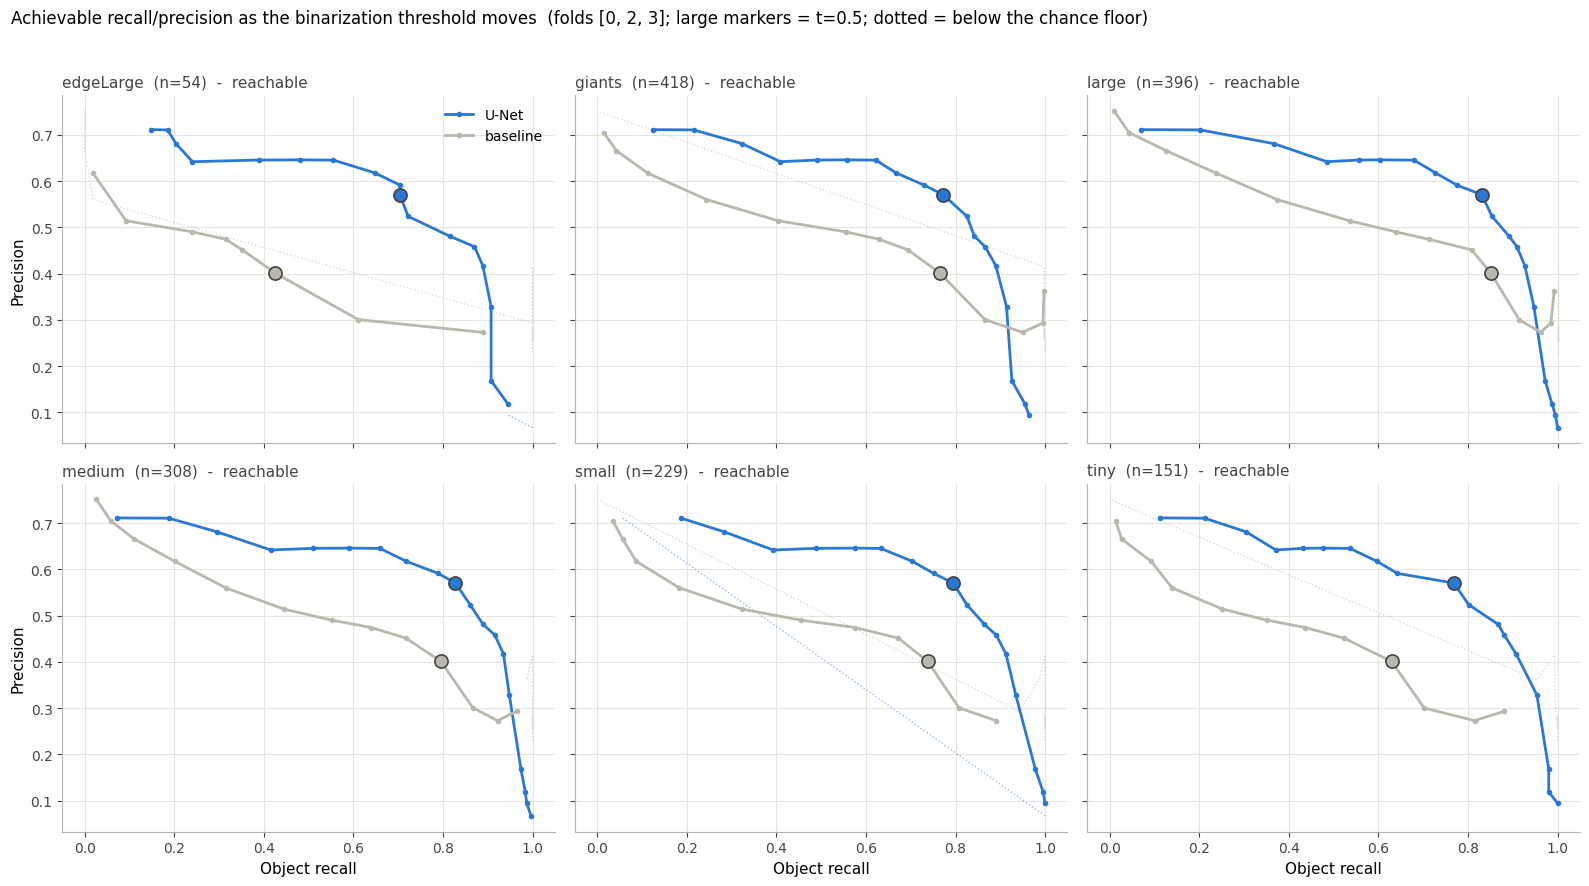

wrote ../outputs/figures/plots/baselinepostproc_reachability.png


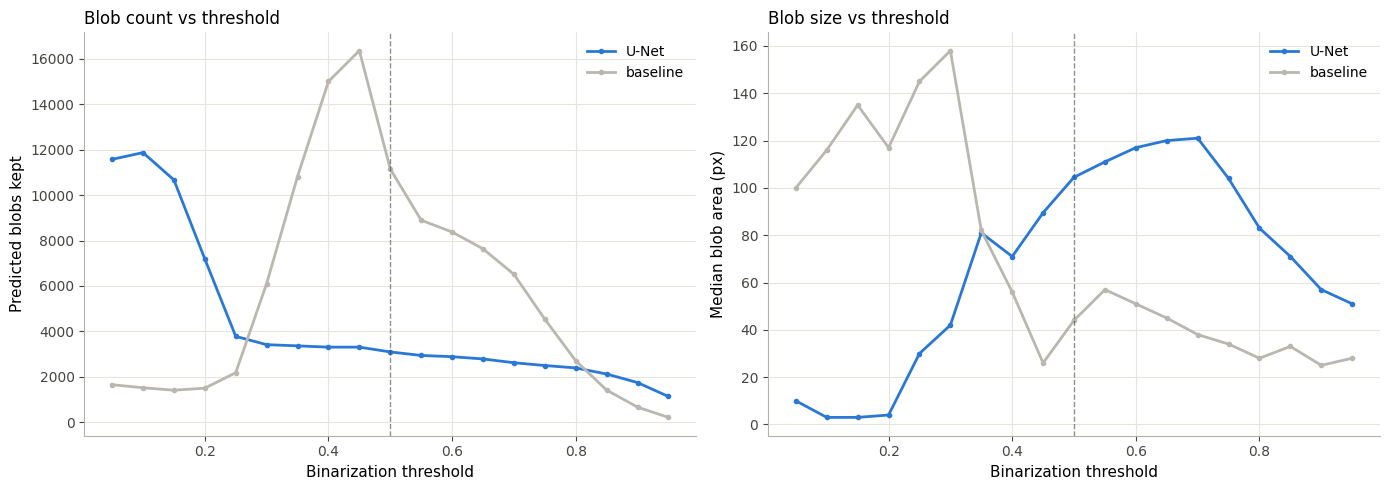

wrote ../outputs/figures/plots/baselinepostproc_blobStructure.png


In [21]:
# --- the reachability figure --------------------------------------------------

BLUE, GRAY, INK = "#2a78d6", "#b9b7ae", "#444441"

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)

for ax, c in zip(axes.ravel(), classes):
    for m, colour, label in [("unet", BLUE, "U-Net"), ("baseline", GRAY, "baseline")]:
        cv = curve(sweeps[m], c)
        good = cv[cv["informative"]]
        dead = cv[~cv["informative"]]
        ax.plot(good["object_recall"], good["precision"], color=colour, lw=2,
                marker="o", ms=3, label=label, zorder=3)
        # degenerate thresholds drawn faint, so the curve is not silently cropped
        ax.plot(dead["object_recall"], dead["precision"], color=colour, lw=1,
                ls=":", alpha=0.5, zorder=2)
        if OPERATING_T in cv.index:
            ax.scatter([cv.loc[OPERATING_T, "object_recall"]],
                       [cv.loc[OPERATING_T, "precision"]],
                       s=90, color=colour, edgecolor=INK, lw=1.2, zorder=5)

    v = verdict.loc[c]
    ax.set_title(f"{c}  (n={int(comparison.loc[c, 'n_bubbles'])})  -  {v['verdict']}",
                 fontsize=11, loc="left", color=INK)
    ax.grid(color="#e6e4dc", lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#b4b2a9")
    ax.tick_params(colors=INK)

for ax in axes[-1]:
    ax.set_xlabel("Object recall", fontsize=11)
for ax in axes[:, 0]:
    ax.set_ylabel("Precision", fontsize=11)
axes[0, 0].legend(frameon=False, fontsize=10)

fig.suptitle("Achievable recall/precision as the binarization threshold moves"
             f"  (folds {kept}; large markers = t={OPERATING_T}; "
             "dotted = below the chance floor)",
             fontsize=12, x=0.01, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.96])
out = os.path.join(PLOTS_DIR, f"{RUN_NAME}{RUN_TAG}reachability.png")
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("wrote", out)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for m, colour, label in [("unet", BLUE, "U-Net"), ("baseline", GRAY, "baseline")]:
    cv = curve(sweeps[m], classes[0])   # blob stats are global, any class works
    axes[0].plot(cv.index, cv["n_pred_blobs"], color=colour, lw=2, marker="o",
                 ms=3, label=label)
    axes[1].plot(cv.index, cv["median_blob_px"], color=colour, lw=2, marker="o",
                 ms=3, label=label)

axes[0].set_ylabel("Predicted blobs kept", fontsize=11)
axes[0].set_title("Blob count vs threshold", fontsize=12, loc="left")
axes[1].set_ylabel("Median blob area (px)", fontsize=11)
axes[1].set_title("Blob size vs threshold", fontsize=12, loc="left")
for ax in axes:
    ax.set_xlabel("Binarization threshold", fontsize=11)
    ax.axvline(OPERATING_T, color=INK, ls="--", lw=1, alpha=0.6)
    ax.legend(frameon=False, fontsize=10)
    ax.grid(color="#e6e4dc", lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#b4b2a9")
    ax.tick_params(colors=INK)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, f"{RUN_NAME}{RUN_TAG}blobStructure.png")
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("wrote", out)


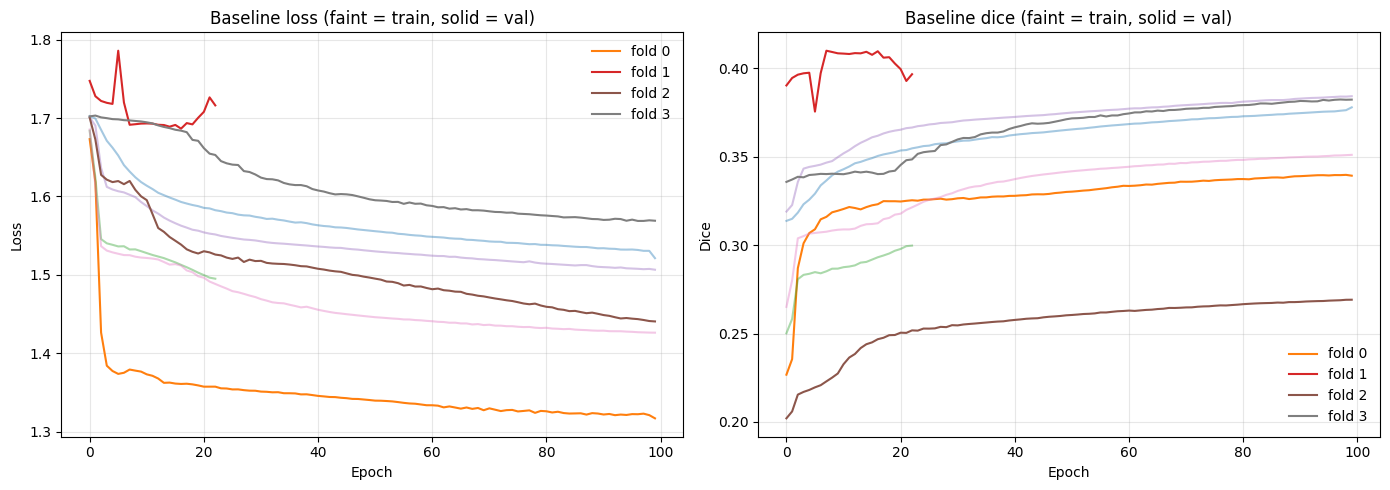

wrote ../outputs/figures/plots/baselinetrainingCurves.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fold, history in histories.items():
    axes[0].plot(history.history["loss"], alpha=0.4)
    axes[0].plot(history.history["val_loss"], label=f"fold {fold}")
    axes[1].plot(history.history["dice_coef"], alpha=0.4)
    axes[1].plot(history.history["val_dice_coef"], label=f"fold {fold}")

axes[0].set_title("Baseline loss (faint = train, solid = val)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].set_title("Baseline dice (faint = train, solid = val)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice")
for ax in axes:
    ax.legend(frameon=False); ax.grid(alpha=0.3)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, f"{RUN_NAME}trainingCurves.png")
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("wrote", out)